This notebook aims to perform geometric calibration for mastcam-Z

Here we aim to transform the CAHVOR vectors from the rover frame $r$ to the mask frame $m$. 

In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation as R

In [2]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")
print(list(data.columns))

Number of data points:3529
['Unnamed: 0', 'name', 'zcam', 'cam', 'fl', 'temp_DEA', 'temp_FPA', 'temp_HTR1', 'temp_HTR2', 'fmc', 'zmc', 'filtmc', 'az_RSM', 'el_RSM', 'c_r', 'a_r', 'h_r', 'v_r', 'o_r', 'r_r', 'c_r_est', 'a_r_est', 'h_r_est', 'v_r_est', 'o_r_est', 'r_r_est', 'f_est', 'cx_est', 'cy_est', 'b1_est', 'b2_est', 'k0_est', 'k1_est', 'k2_est', 'k3_est', 'k4_est', 'p1_est', 'p2_est', 'f', 'cx', 'cy', 'b1', 'b2', 'k0', 'k1', 'k2', 'k3', 'k4', 'p1', 'p2', 'w', 'h', 'X_ref', 'Y_ref', 'Z_ref', 'X_est', 'Y_est', 'Z_est', 'KnKR_e_c_est', 'q_rpm', 'R_rpm', 't_rpm', 'fmc_ref', 'filt', 'filt_ref', 'valid', 'q_rrp', 'R_rrp', 't_rrp', 's_rrp', 'q_rpr', 'R_rpr', 't_rpr', 's_rpr', 'cahvor_r', 'cahvor_rp', 'cahvor_m', 'cahvor_r_est', 'cahvor_rp_est', 'cahvor_m_est', 'cahvor_r_mst', 'cahvor_rp_mst', 'cahvor_m_mst', 'q_mc', 'R_mc', 't_mc', 'K_c', 'q_mc_est', 'R_mc_est', 't_mc_est', 'K_c_est', 'q_mc_mst', 'R_mc_mst', 't_mc_mst', 'K_c_mst']


In [3]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# tranformation from rover frame r to approximate rover frame r'
q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
R_rrp = R.from_quat(q_rrp).as_matrix()
t_rrp = np.array([0.0007,  0.003,   0.0006])
s_rrp = 0.998
trans_rrp = lambda v: s_rrp * (R_rrp @ v + t_rrp)

# transformation from rover frame r' to mast frame m
def get_trans_rpm(data, idx):
  """
  Returns a lambda function that takes a 3d vector in rover frame 
  and returns the vector in approximate rover frame 
  """
  R_rpm = to_mat(data["R_rpm"][idx])
  t_rpm = to_vec_comma(data["t_rpm"][idx])
  s_rpm = 1

  return lambda v: s_rpm * (R_rpm @ v + t_rpm)



In [ ]:
# add additional data columns
for c_name in ["c", "a", "h", "v", "o", "r"]:
  data[c_name+"_rp"] = [None]*data.shape[0]
for c_name in ["c", "a", "h", "v", "o", "r"]:
  data[c_name+"_rp_est"] = [None]*data.shape[0]
for c_name in ["c", "a", "h", "v", "o", "r"]:
  data[c_name+"_m"] = [None]*data.shape[0]
for c_name in ["c", "a", "h", "v", "o", "r"]:
  data[c_name+"_m_est"] = [None]*data.shape[0]



for idx in range(data.shape[0]):
  trans_rpm = get_trans_rpm(data, idx)
  cahvor_r = [to_vec_comma(data[c_name+"_r"][idx]) for c_name in ["c", "a", "h", "v", "o", "r"]]
  cahvor_est_r = [to_vec_space(data[c_name+"_r_est"][idx]) for c_name in ["c", "a", "h", "v", "o", "r"]]

  # transfrom from rover frame r to approximate rover frame r'
  cahvor_rp = [trans_rrp(cahvor_r_vec) for cahvor_r_vec in cahvor_r]
  cahvor_est_rp = [trans_rrp(cahvor_est_r_vec) for cahvor_est_r_vec in cahvor_est_r]

  # transform from approximate rover frame r' to mast frame m
  cahvor_m = [trans_rpm(cahvor_rp_vec) for cahvor_rp_vec in cahvor_rp]
  cahvor_est_m = [trans_rpm(cahvor_est_rp_vec) for cahvor_est_rp_vec in cahvor_est_rp]

  for i, c_name in enumerate(["c", "a", "h", "v", "o", "r"]):
    data[c_name+"_rp"][idx] = cahvor_rp[i]
    data[c_name+"_rp_est"][idx] = cahvor_est_rp[i]

    data[c_name+"_m"][idx] = cahvor_m[i]
    data[c_name+"_m_est"][idx] = cahvor_est_m[i]

    

In [5]:
# save the file
data.to_excel("data/m41_site_cal_v227_v8_processed.xlsx", index=False)

## Geometric Calibration

For each ZL034 and ZR034 we will find a model of the focal length $fl$ as a function of focus motor-count $fmc$. The model would be a simple line, given as 

$$fl(fmc) = \alpha_{fl} + \beta_{fl} \cdot fmc$$

Let $D_{fl-fmc,ZL34}=\left\{(fl_{l,0}, fmc_{l,0}), (fl_{l,1}, fmc_{l,1}), \dots, (fl_{l,n}, fmc_{l,n})\right\}$ be the set of zcam left 34mm focal length and focus motor count pairs and let $D_{fl-fmc,ZR34}=\left\{(fl_{r,0}, fmc_{r,0}), (fl_{r,1}, fmc_{r,1}), \dots, (fl_{r,n}, fmc_{r,n})\right\}$ be the corresponding dataset of the right zcam. 

Need to solve 

$$\min_{\alpha_l, \beta_l} \sum_{i=0}^n ( (\beta_l \cdot fmc_i +  \alpha_l) - fl_i)^2$$
for $\alpha_l, \beta_l$. 

To do so, we utilize the normal equation 

$$\theta_l = (X_l^TX_l)^{-1}X_l^TY_l$$
where 
\begin{align*}
  \theta=\begin{bmatrix}\beta_l\\\alpha_l\end{bmatrix} &&
  X_l = \begin{bmatrix}fmc_{l,0}&&1\\fmc_{l,1}&&1\\ \vdots&&1 \\fmc_{l,n}&&1\end{bmatrix} &&
  Y_l = \begin{bmatrix}fl_{l,0}\\fl_{l,1}\\\vdots\\fl_{l,n}\end{bmatrix}
\end{align*}

where the inverse we use would be the penrose pseudo-inverse. 


Similarly for the right cameras, 
$$\alpha_r, \beta_r = \arg\min_{\alpha_r, \beta_r} \sum_{i=0}^n ( (\beta_r \cdot fmc_i +  \alpha_r) - fl_i)^2$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_fpath = "data/m41_site_cal_v227_v8_processed.xlsx"
data = pd.read_excel(data_fpath)

zl34 = data[data["cam"] == "ZL034"].copy()
zr34 = data[data["cam"] == "ZR034"].copy()

print(f"Number of data points for zl034:{zl34.shape[0]}")
print(f"Number of data points for zr034:{zr34.shape[0]}")

Number of data points for zl034:344
Number of data points for zr034:323


X_l shape:(344, 2); Y_l shape:(344,); theta_l:[5.01639695e-02 4.68209789e+03]; MSE_l:101.042097
X_r shape:(323, 2); Y_r shape:(323,); theta_r:[5.31455367e-02 4.68747381e+03]; MSE_r:143.618222


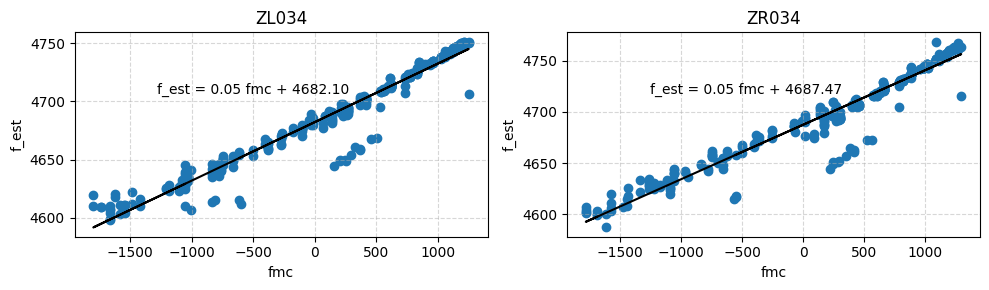

In [2]:
## solve for an approx BFL to identfy outliers

# solve for theta_left
X_l = np.vstack([zl34["fmc"], np.ones(zl34.shape[0])]).T
Y_l = zl34["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

print(f"X_l shape:{X_l.shape}; Y_l shape:{Y_l.shape}; theta_l:{theta_l}; MSE_l:{residual_l:0.6f}")

# solve for theta_right
X_r = np.vstack([zr34["fmc"], np.ones(zr34.shape[0])]).T
Y_r = zr34["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"X_r shape:{X_r.shape}; Y_r shape:{Y_r.shape}; theta_r:{theta_r}; MSE_r:{residual_r:0.6f}")

# plot Y_l as a funciton of X_l with the line of best fit
fig, ax = plt.subplots(1, 2, figsize=(10,3))

# left focal-length as a function of fmc
ax[0].scatter(zl34["fmc"], zl34["f_est"], label="f_est")
ax[0].plot(zl34["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# right focal-length as a function of fmc
ax[1].scatter(zr34["fmc"], zr34["f_est"], label="f_est")
ax[1].plot(zr34["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)


plt.tight_layout()
plt.show()

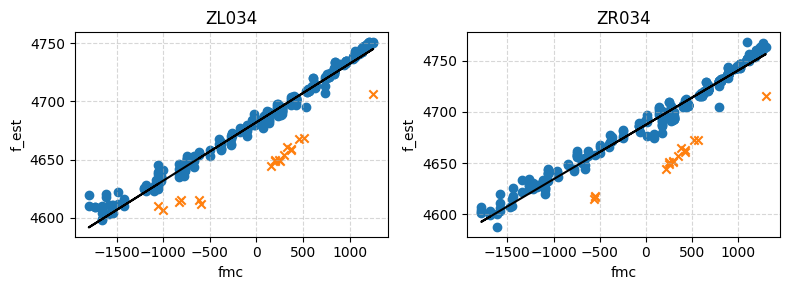

In [7]:
# Here we manually identify the outliers


# identify the outliers
zl34["residual"] = (zl34["f_est"] - (X_l @ theta_l))
zr34["residual"] = (zr34["f_est"] - (X_r @ theta_r))
# print(f"Left outlier idx:{zl34['residual'].abs() > 18}")
# print(f"right outlier idx:{zr34['residual'].abs() > 18}")
      
left_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1101, 1113, 1122, 1793, 2610, 2620]
right_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 1203, 1758, 2658]
left_cfm_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1113, 1122, 1793]
right_cfm_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 2658]

zl34["outlier"] = zl34.index.isin(left_cfm_outlier_idx)
zr34["outlier"] = zr34.index.isin(right_cfm_outlier_idx)


# plot the points that are not outliers and those that are outliers on the same plot with different markers
fig, ax = plt.subplots(1, 2, figsize=(8,3))

# left focal-length as a function of fmc
ax[0].scatter(zl34[~zl34["outlier"]]["fmc"], zl34[~zl34["outlier"]]["f_est"], label="f_est", marker="o")
ax[0].scatter(zl34[zl34["outlier"]]["fmc"], zl34[zl34["outlier"]]["f_est"], label="outlier", marker="x")
# ax[0].scatter(zl34.loc[left_outlier_idx]["fmc"], zl34.loc[left_outlier_idx]["f_est"], label="outlier", marker="x", color="orange")
# ax[0].scatter(zl34.loc[left_cfm_outlier_idx]["fmc"], zl34.loc[left_cfm_outlier_idx]["f_est"], label="outlier", marker="x", color="black")
ax[0].plot(zl34["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)

# right focal-length as a function of fmc
ax[1].scatter(zr34[~zr34["outlier"]]["fmc"], zr34[~zr34["outlier"]]["f_est"], label="f_est", marker="o")
ax[1].scatter(zr34[zr34["outlier"]]["fmc"], zr34[zr34["outlier"]]["f_est"], label="outlier", marker="x")
# ax[1].scatter(zr34.loc[right_outlier_idx]["fmc"], zr34.loc[right_outlier_idx]["f_est"], label="outlier", marker="x")
# ax[1].scatter(zr34.loc[right_cfm_outlier_idx]["fmc"], zr34.loc[right_cfm_outlier_idx]["f_est"], label="outlier", marker="x", color="black")

ax[1].plot(zr34["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

alpha_l:4684.257100; beta_l:0.0497613; MSE_l:21.148778
alpha_r:4689.772199; beta_r:0.053044; MSE_r:38.618437


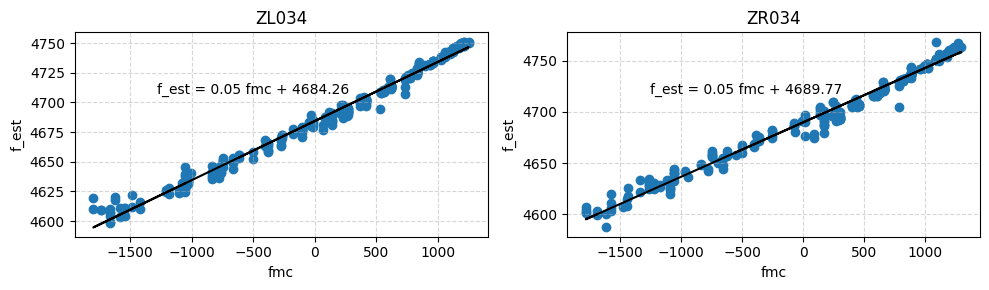

In [22]:
# Here we perform the same fit without the outliers

# outliers we identified above; copying code so we dont have to run above cell
## TODO: find the image names
left_cfm_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1113, 1122, 1793]
right_cfm_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 2658]
zl34["outlier"] = zl34.index.isin(left_cfm_outlier_idx)
zr34["outlier"] = zr34.index.isin(right_cfm_outlier_idx)

# perform the same fit without the outliers
X_l = np.vstack([zl34[~zl34["outlier"]]["fmc"], np.ones(zl34[~zl34["outlier"]].shape[0])]).T
Y_l = zl34[~zl34["outlier"]]["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

X_r = np.vstack([zr34[~zr34["outlier"]]["fmc"], np.ones(zr34[~zr34["outlier"]].shape[0])]).T
Y_r = zr34[~zr34["outlier"]]["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"alpha_l:{theta_l[1]:.6f}; beta_l:{theta_l[0]:.6}; MSE_l:{residual_l:0.6f}")
print(f"alpha_r:{theta_r[1]:.6f}; beta_r:{theta_r[0]:.6}; MSE_r:{residual_r:0.6f}")

# plot the point thar are not outliers and the line of best fit found without the outliers
fig, ax = plt.subplots(1, 2, figsize=(10,3))
# left focal-length as a function of fmc
ax[0].scatter(zl34[~zl34["outlier"]]["fmc"], zl34[~zl34["outlier"]]["f_est"], label="f_est", marker="o")
ax[0].plot(zl34[~zl34["outlier"]]["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)

# right focal-length as a function of fmc
ax[1].scatter(zr34[~zr34["outlier"]]["fmc"], zr34[~zr34["outlier"]]["f_est"], label="f_est", marker="o")
ax[1].plot(zr34[~zr34["outlier"]]["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.2, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)

plt.tight_layout()
plt.show()

In [11]:
left_cfm_outlier_idx = [2, 34, 35, 36, 37, 38, 39, 41, 48, 54, 215, 549, 917, 1083, 1096, 1113, 1122, 1793]
right_cfm_outlier_idx = [218, 219, 253, 254, 255, 256, 257, 258, 260, 267, 273, 788, 815, 942, 2658]

with open("focal_length_outliers.txt", "a+") as f:
  for name in zl34[zl34.index.isin(left_cfm_outlier_idx)]['name']:
    f.write(name+"\n")
  for name in zr34[zr34.index.isin(right_cfm_outlier_idx)]['name']:
    f.write(name+"\n")

## Modelling $R_M^C$

Here we want to model the rotation matrix from the mast frame to the camera frame. For a given data point $i$, let 
$H^r = \begin{bmatrix}h_i^T\\v_i^T\\a_i^T\end{bmatrix}$. Then $R_M^C$ is related to $H^r$ by the following

$$ H^r =  K^C R_C^M R_M^{r'} R_{r'}^r$$

let computed value of $H^r$ using the model be $H'_i = K^C R_C^M R_M^{r'} R_{r'}^r$.

$$
\begin{align*}
H'_i 
&= \begin{bmatrix} H'_{00} & H'_{01} & H'_{02}\\ H'_{10} & H'_{11} & H'_{12}\\ H'_{20} & H'_{21} & H'_{22}\end{bmatrix}\\
&= \begin{bmatrix}fl+b_1 & b_2 & c_x\\ 0 & fl & c_y \\ 0 & 0 & 1\end{bmatrix}
\begin{bmatrix}R_{00}&R_{01}&R_{02}\\R_{10}&R_{11}&R_{12}\\ R_{20}&R_{21}&R_{22}\\\end{bmatrix}
\begin{bmatrix}r_{00}&r_{01}&r_{02}\\ r_{10}&r_{11}&r_{12}\\ r_{20}&R_{21}&r_{22}\\\end{bmatrix}\\

&= 
\begin{bmatrix}

\sum_{j=1}^3 ((fl+b)R_{0j}+b_2R_{1j}+c_xR_{2j})r_{j0} & \sum_{j=1}^3 ((fl+b)R_{0j}+b_2R_{1j}+c_xR_{2j})r_{j1} & \sum_{j=1}^3 ((fl+b)R_{0j}+b_2R_{1j}+c_xR_{2j})r_{j2}\\
\sum_{j=1}^3 (fl \cdot R_{1j} + c_yR_{2j})r_{j0} & \sum_{j=1}^3 (fl \cdot R_{1j} + c_yR_{2j})r_{j1} & \sum_{j=1}^3 (fl \cdot R_{1j} + c_yR_{2j})r_{j2}\\
\sum_{j=1}^3 R_{2j}r_{j0} & \sum_{j=1}^3 R_{2j}r_{j1} & \sum_{j=1}^3 R_{2j}r_{j2}

\end{bmatrix}
\end{align*}
$$


We are modelling 
$R_M^C 
\leftarrow q_\alpha + q_\beta * fmc 
= \begin{bmatrix}\alpha_0\\\alpha_1\\\alpha_2\\\alpha_3\end{bmatrix} +
\begin{bmatrix}\beta_0\\\beta_1\\\beta_2\\\beta_3\end{bmatrix}*f
= \begin{bmatrix}\alpha_0 + \beta_0 f_0\\ \alpha_1 + \beta_1 f_1 \\ \alpha_2 + \beta_2 f_2 \\ \alpha_3 + \beta_3 f_3 \end{bmatrix}
= \begin{bmatrix} q_0\\q_1\\q_2\\q_3 \end{bmatrix}
$, then

$$ R_M^C 
= \begin{bmatrix}R_{00}&R_{01}&R_{02}\\R_{10}&R_{11}&R_{12}\\ R_{20}&R_{21}&R_{22}\\\end{bmatrix}
= \begin{bmatrix}
2(q_0^2 + q_1^2)-1 & 2(q_1q_2-q_0q_3) & 2(q_1q_3+q_0q_2)\\
2(q_1q_2 + q_0q_3) & 2(q_0^2+q_2^2)-1 & 2(q_2q_3-q_0q_1)\\
2(q_1q_3+q_0q_2) & 2(q_2q_3 + q_0q_1) & 2(q_0^2+q_3^2) -1
\end{bmatrix}
$$

Need to solve for $\alpha_0,\alpha_1, \alpha_2, \alpha_3, \beta_0, \beta_1, \beta_2, \beta_3$ 

$$

\min \left\| 
    \begin{bmatrix}H_{00}\\ H_{01}\\ H_{02}\\ H_{10}\\ H_{11}\\ H_{12}\\ H_{20}\\ H_{21}\\ H_{22}\\ \end{bmatrix} -
    \begin{bmatrix}H'_{00}\\ H'_{01}\\ H'_{02}\\ H'_{10}\\ H'_{11}\\ H'_{12}\\ H'_{20}\\ H'_{21}\\ H'_{22}\\ \end{bmatrix} 
  \right\|_2

= \min \sum_{i,j} (H_{ij} - H'_{ij})^2

$$

Here we will use the BFGS algorithm from Scipy to find the minimum. Due to the the larger number of parameters involved, we would not compute the jacobian and instead estimate the jacobian by first difference.


In [166]:
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
from scipy.optimize import NonlinearConstraint
from tqdm import tqdm
import matplotlib.pyplot as plt

In [85]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")
print(data.columns)

Number of data points:3529
Index(['Unnamed: 0', 'name', 'zcam', 'cam', 'fl', 'temp_DEA', 'temp_FPA',
       'temp_HTR1', 'temp_HTR2', 'fmc', 'zmc', 'filtmc', 'az_RSM', 'el_RSM',
       'c_r', 'a_r', 'h_r', 'v_r', 'o_r', 'r_r', 'c_r_est', 'a_r_est',
       'h_r_est', 'v_r_est', 'o_r_est', 'r_r_est', 'f_est', 'cx_est', 'cy_est',
       'b1_est', 'b2_est', 'k0_est', 'k1_est', 'k2_est', 'k3_est', 'k4_est',
       'p1_est', 'p2_est', 'f', 'cx', 'cy', 'b1', 'b2', 'k0', 'k1', 'k2', 'k3',
       'k4', 'p1', 'p2', 'w', 'h', 'X_ref', 'Y_ref', 'Z_ref', 'X_est', 'Y_est',
       'Z_est', 'KnKR_e_c_est', 'q_rpm', 'R_rpm', 't_rpm', 'fmc_ref', 'filt',
       'filt_ref', 'valid', 'q_rrp', 'R_rrp', 't_rrp', 's_rrp', 'q_rpr',
       'R_rpr', 't_rpr', 's_rpr', 'cahvor_r', 'cahvor_rp', 'cahvor_m',
       'cahvor_r_est', 'cahvor_rp_est', 'cahvor_m_est', 'cahvor_r_mst',
       'cahvor_rp_mst', 'cahvor_m_mst', 'q_mc', 'R_mc', 't_mc', 'K_c',
       'q_mc_est', 'R_mc_est', 't_mc_est', 'K_c_est', 'q_mc_mst', 'R_

In [86]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]

data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


In [87]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}

# form the ground truth H matrix
def get_H_gt(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = data_["h_r_vec"][idx]
  v_i = data_["v_r_vec"][idx]
  a_i = data_["a_r_vec"][idx]
  H_i = np.vstack([h_i, v_i, a_i])

  return H_i

def get_R_rm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Calculates R_rpm @ R_rrp
  """
  R_rpm = data_["R_rpm_mat"][idx]
  q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
  R_rrp = R.from_quat(q_rrp).as_matrix()

  return R_rpm @ R_rrp

def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_R_mc(a0:float, a1:float, a2:float, a3:float,
            b0:float, b1:float, b2:float, b3:float,
            idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the R_mc matrix where a0...a3 are the constants and b0...b3 are the scalar multiples
  """
  f = data_["fmc"][idx]

  
  q_mc = np.array([a0+b0*f, a1+b1*f, a2+b2*f, a3+b3*f])
  q_mc = q_mc / np.linalg.norm(q_mc)

  R_mc = R.from_quat(q_mc).as_matrix()

  return R_mc

def get_H_prime(a0:float, a1:float, a2:float, a3:float,
            b0:float, b1:float, b2:float, b3:float,
            idx:int, data_:np.ndarray):
  
  """
  Calculates the apprimaxations of H where a0...a3, b0...b3 are the quaternions for the rotation
  """
  Kc = get_KC(idx, data_)
  R_mc = get_R_mc(a0, a1, a2, a3, b0, b1, b2, b3, idx, data_)
  R_rm = get_R_rm(idx, data_)
  H_prime = Kc @ R_mc @ R_rm

  return H_prime

def error(H:np.ndarray, H_prime:np.ndarray)->float:
  return np.sum(np.abs((H - H_prime)/H))

def error2(H:np.ndarray, H_prime:np.ndarray)->float:
  rel_h_diff = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
  rel_v_diff = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
  rel_a_diff = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])
  return rel_h_diff + rel_v_diff + rel_a_diff

def obj(x):
  """
  returns value of the objective function at x, where 
  x = [a0, a1, a2, a3, b0, b1, b2, b3]
  """
  a0, a1, a2, a3, b0, b1, b2, b3 = x
  total_rel_error = 0
  for idx in range(data.shape[0]):
    H = get_H_gt(idx, data)
    H_prime = get_H_prime(a0, a1, a2, a3, b0, b1, b2, b3, idx, data)
    rel_error = error(H, H_prime)

    total_rel_error += rel_error
  
  return total_rel_error/data.shape[0]

###### Distribution of quaternions

Here we look at the distribution of the $q_{mc}$ for the ZL034 and ZR034

From the relation of $H^r = K^c R_c^m R^{r'}_m R^r_{r'}$, we get 
  $$R_c^m = (K^c)^{-1} H^r (R_{r'}^r)^{-1} (R_m^{r'})^{-1}$$
Now because $R_{r'}^r$ and $R_m^{r'}$ are orthogonal matrices, so 
$(R_{r'}^r)^{-1} = (R_{r'}^r)^T $ and 
$(R_m^{r'})^{-1} = (R_m^{r'})^T$. Observe that $K^c$ is an upper triangular matrix
and there are no zeros on the main diagonal, so it is invertible. The inverse can 
be attained by using backward substitution

$$ (K^c)^{-1} = 
\begin{bmatrix} 
  \frac{1}{f+b_1} & -\frac{b_2}{f(f+b_1)} & \frac{c_yb_2}{f(f+b_1)}-\frac{c_x}{f+b_1}\\
  0 & \frac{1}{f} & -\frac{c_y}{f}\\
  0 & 0 & 1
\end{bmatrix} $$


In [126]:
# calculate the quaternions for each data point
data["q_mc"] = [None]*data.shape[0]
q0s, q1s, q2s, q3s = [], [], [], []
for idx in range(data.shape[0]):
  Kc_inv = get_KC_inv(idx, data)
  H = get_H_gt(idx, data)
  R_rm = get_R_rm(idx, data)

  R_mc = Kc_inv @ H @ R_rm 
  rot = R.from_matrix(R_mc)
  q_mc = rot.as_quat()
  if (q_mc[0]<0):
    q_mc = -q_mc
  q0s.append(q_mc[0])
  q1s.append(q_mc[1])
  q2s.append(q_mc[2])
  q3s.append(q_mc[3])
  
data["q_mc_0"], data["q_mc_1"], data["q_mc_2"], data["q_mc_3"] = q0s, q1s, q2s, q3s

Mean ZL034 q_mc:(0.489525, 0.508784, 0.503247, -0.498243)
Mean ZR034 q_mc:(0.506327, 0.489803, 0.495380, -0.508189)


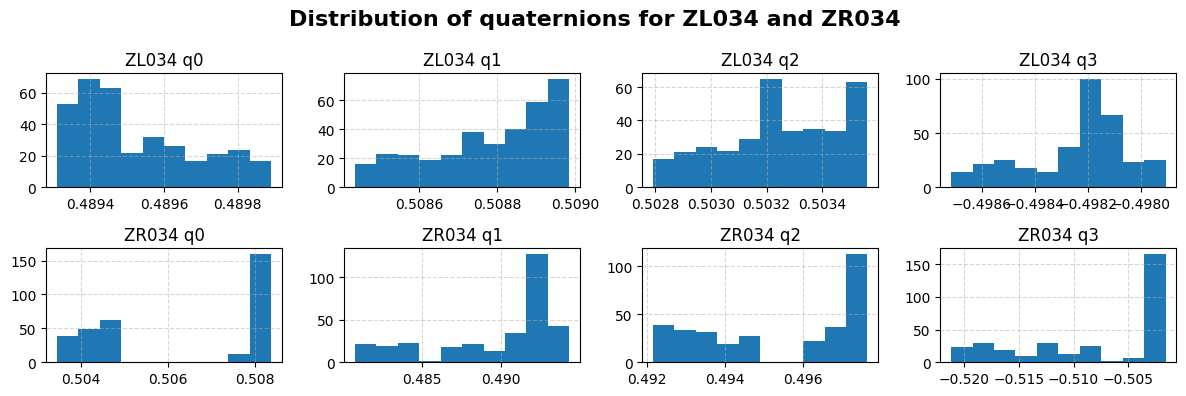

In [131]:
# find the average quaternion for ZL034
zl034_data = data[data["cam"] == "ZL034"].copy()
zl034_q0_mean = zl034_data["q_mc_0"].mean()
zl034_q1_mean = zl034_data["q_mc_1"].mean()
zl034_q2_mean = zl034_data["q_mc_2"].mean()
zl034_q3_mean = zl034_data["q_mc_3"].mean()

print(f"Mean ZL034 q_mc:({zl034_q0_mean:.6f}, {zl034_q1_mean:.6f}, {zl034_q2_mean:.6f}, {zl034_q3_mean:.6f})")

# find the average quaternion for ZR034
zr034_data = data[data["cam"] == "ZR034"].copy()
zr034_q0_mean = zr034_data["q_mc_0"].mean()
zr034_q1_mean = zr034_data["q_mc_1"].mean()
zr034_q2_mean = zr034_data["q_mc_2"].mean()
zr034_q3_mean = zr034_data["q_mc_3"].mean()

print(f"Mean ZR034 q_mc:({zr034_q0_mean:.6f}, {zr034_q1_mean:.6f}, {zr034_q2_mean:.6f}, {zr034_q3_mean:.6f})")

# plot the distrubution of each component of the quaternion for zl034 and zr034
fig, ax = plt.subplots(2, 4, figsize=(12,4))

ax[0, 0].hist(zl034_data["q_mc_0"])
ax[0, 0].set_title("ZL034 q0")
ax[0, 0].grid(linestyle="--", alpha=0.5)

ax[0, 1].hist(zl034_data["q_mc_1"])
ax[0, 1].set_title("ZL034 q1")
ax[0, 1].grid(linestyle="--", alpha=0.5)

ax[0, 2].hist(zl034_data["q_mc_2"])
ax[0, 2].set_title("ZL034 q2")
ax[0, 2].grid(linestyle="--", alpha=0.5)

ax[0, 3].hist(zl034_data["q_mc_3"])
ax[0, 3].set_title("ZL034 q3")
ax[0, 3].grid(linestyle="--", alpha=0.5)

ax[1, 0].hist(zr034_data["q_mc_0"])
ax[1, 0].set_title("ZR034 q0")
ax[1, 0].grid(linestyle="--", alpha=0.5)

ax[1, 1].hist(zr034_data["q_mc_1"])
ax[1, 1].set_title("ZR034 q1")
ax[1, 1].grid(linestyle="--", alpha=0.5)

ax[1, 2].hist(zr034_data["q_mc_2"])
ax[1, 2].set_title("ZR034 q2")
ax[1, 2].grid(linestyle="--", alpha=0.5)

ax[1, 3].hist(zr034_data["q_mc_3"])
ax[1, 3].set_title("ZR034 q3")
ax[1, 3].grid(linestyle="--", alpha=0.5)


plt.suptitle("Distribution of quaternions for ZL034 and ZR034", fontsize=16, fontweight="bold")
plt.tight_layout()

## ZL034 Fitting

Here we will fit the rotation $R_C^M$ for the ZL034, subjected to the constraint that the alpha quaternions have a norm of 1

In [146]:
def gen_obj(data_, err_fn):
  """
  Generates an objective function to be minimized given the 
  data set and the error funciton
  """

  def obj(x):
    """
    returns value of the objective function at x, where 
    x = [a0, a1, a2, a3, b0, b1, b2, b3]
    """
    a0, a1, a2, a3, b0, b1, b2, b3 = x
    total_rel_error = 0
    for idx in range(data_.shape[0]):
      H = get_H_gt(idx, data_)
      H_prime = get_H_prime(a0, a1, a2, a3, b0, b1, b2, b3, idx, data_)
      rel_error = err_fn(H, H_prime)

      total_rel_error += rel_error

    return total_rel_error/data_.shape[0]
  
  return obj

def sum_vec_rel_err(H:np.ndarray, H_prime:np.ndarray)->float:
  rel_h_diff = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
  rel_v_diff = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
  rel_a_diff = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])
  return rel_h_diff + rel_v_diff + rel_a_diff

alpha: [ 0.49477377  0.47362567  0.51825208 -0.51214492]
beta: [ 0.00030034  0.00019821  0.00025602 -0.00051598]
final obj function value:3.0213595561383144
Objective function on mean:3.162761


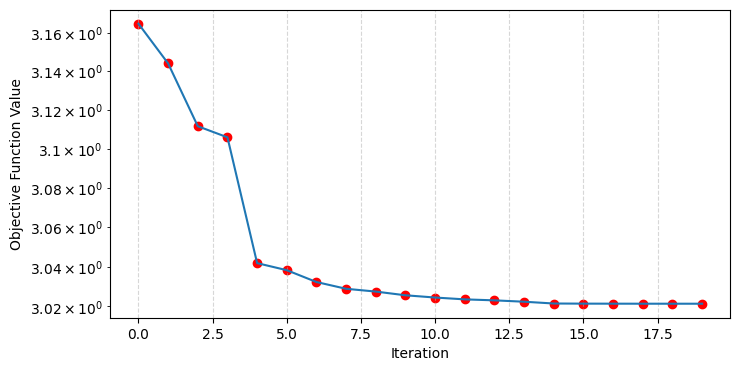

In [163]:
# filter dataset for ZL034
zl034_data = data[data["cam"] == "ZL034"].copy().reset_index(drop=True)

zl034_obj = gen_obj(zl034_data, sum_vec_rel_err)
zl034_x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res = minimize(zl034_obj, zl034_x0, method="BFGS", options={"return_all":True})

# normalize the first four
alpha = res.x[:4]
alpha = alpha / np.linalg.norm(alpha)
beta  = res.x[4:]

print(f"alpha: {alpha}")
print(f"beta: {beta}")
print(f"final obj function value:{res.fun}")

# objective funciton value on the mean gotten from the data
x_mean = [0.489525, 0.508784, 0.503247, -0.498243, 0, 0, 0, 0]
obj_on_mean = zl034_obj(x_mean)
print(f"Objective function on mean:{obj_on_mean:6f}")

# plot the error as a function of iteration
errs = [zl034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")


In [175]:
# constrain |\alpha|=1
cons = ({'type': 'eq', 'fun': lambda x:  np.linalg.norm(x[:4])-1})
bnds = ((0,None), )

res = minimize(zl034_obj, zl034_x0, method="SLSQP", bounds=bnds, constraints=cons, options={"disp":True})

# normalize the first four
alpha = res.x[:4]
alpha = alpha / np.linalg.norm(alpha)
beta  = res.x[4:]

print(f"alpha: {alpha}")
print(f"beta: {beta}")
print(f"final obj function value:{res.fun}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 3.158495249630723
            Iterations: 19
            Function evaluations: 192
            Gradient evaluations: 19
alpha: [0.00000000e+00 5.51827164e-01 8.33958501e-01 6.00940450e-19]
beta: [2.99112801e-02 2.18945600e-01 2.60060082e-01 1.85486336e-17]
final obj function value:3.158495249630723


In [179]:
# constrain |\alpha|=1
cons = ({'type': 'ineq', 'fun': lambda x:  np.linalg.norm(x[:4])-1})
bnds = ((0,None), )

res = minimize(zl034_obj, zl034_x0, method="COBYLA", bounds=bnds, constraints=cons, options={"disp":True})

# normalize the first four
alpha = res.x[:4]
alpha = alpha / np.linalg.norm(alpha)
beta  = res.x[4:]

print(f"alpha: {alpha}")
print(f"beta: {beta}")
print(f"final obj function value:{res.fun}")

alpha: [8.71527592e-02 6.43379436e-01 7.60570374e-01 5.81329794e-05]
beta: [-3.04556169e-18 -9.55921544e-21 -1.50198013e-20 -3.04771094e-18]
final obj function value:3.1598569889502297


In [180]:
# constrain |\alpha|=1
cons = ({'type': 'ineq', 'fun': lambda x:  np.linalg.norm(x[:4])-1})
bnds = ((0,None), )

res = minimize(zl034_obj, zl034_x0, method="trust-constr", bounds=bnds, constraints=cons, options={"disp":True})

# normalize the first four
alpha = res.x[:4]
alpha = alpha / np.linalg.norm(alpha)
beta  = res.x[4:]

print(f"alpha: {alpha}")
print(f"beta: {beta}")
print(f"final obj function value:{res.fun}")

c:\Users\ongyi\anaconda3\envs\MPPP\lib\site-packages\scipy\optimize\_differentiable_functions.py:504: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(delta_x, delta_g)
c:\Users\ongyi\anaconda3\envs\MPPP\lib\site-packages\scipy\optimize\_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


`xtol` termination condition is satisfied.
Number of iterations: 468, function evaluations: 5058, CG iterations: 1664, optimality: 2.44e-07, constraint violation: 0.00e+00, execution time: 1.3e+02 s.
alpha: [5.52450945e-06 6.13802215e-01 7.89459841e-01 1.07865249e-05]
beta: [1.29116387e+00 9.84040704e+00 1.16880910e+01 4.04575120e-06]
final obj function value:3.1575513050896125


#### Tuning BFGS

1. We will the termination condition for 

* gtol: Terminate successfully if gradient norm less than gtol

* xrtol: relative tolerance for x. Terminates successfully if step size is less than xk * xrtol

2. eps: absolute step size for forward Jacobian Approximation

3. Line search parameters:

  * C1
  
  * C2

In [199]:
# here we will tune the eps value that is used

eps_values = [1e-11,1e-10,1e-9,1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]

zl034_data = data[data["cam"] == "ZL034"].copy().reset_index(drop=True)
zl034_obj = gen_obj(zl034_data, sum_vec_rel_err)
zl034_x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]

results = []
for eps in tqdm(eps_values):
  res = minimize(zl034_obj, zl034_x0, method="BFGS", options={"return_all":True, "eps":eps})
  results.append(res)

100%|██████████| 9/9 [02:15<00:00, 15.11s/it]


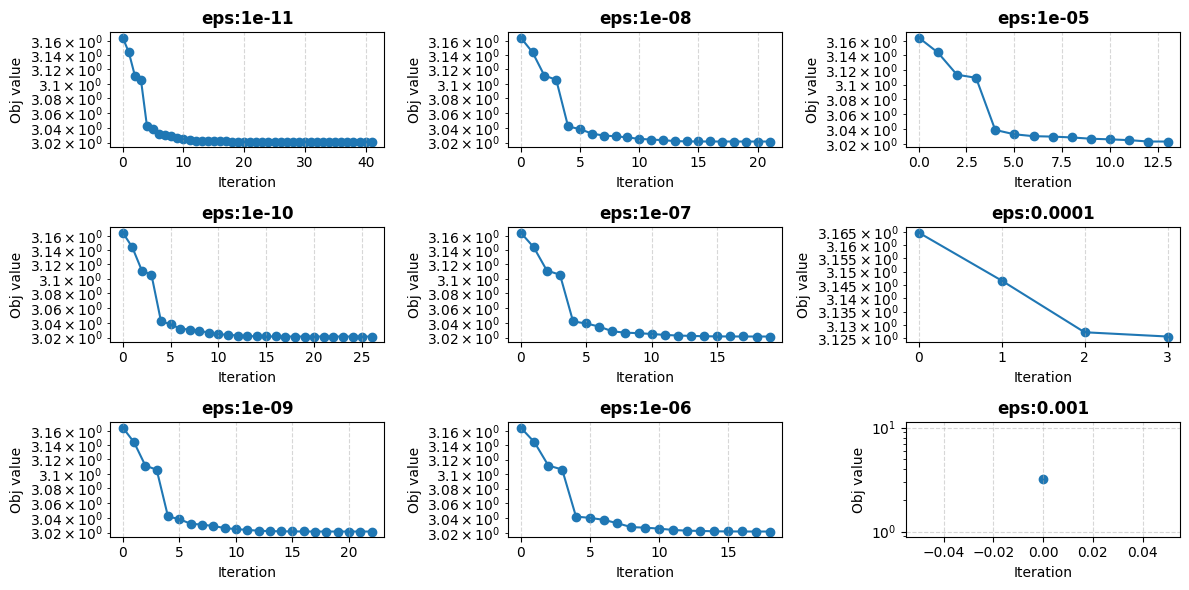

In [200]:
fig, ax = plt.subplots(3, 3, figsize=(12,6))

for i,res in enumerate(results):
  errs = [zl034_obj(x) for x in res.allvecs]

  # plot the error as a function of iteration
  r, c = i%3, i//3 
  ax[r,c].plot(errs)
  ax[r,c].scatter(range(len(errs)), errs)
  ax[r,c].set_title(f"eps:{eps_values[i]}", fontweight="bold")
  ax[r,c].set_xlabel("Iteration")
  ax[r,c].set_ylabel("Obj value")
  ax[r,c].grid(linestyle="--", alpha=0.5)
  ax[r,c].set_yscale("log")

  plt.tight_layout()

#### BFGS with Finite Differencing

Here we run BFGS for two different initial starting points $[0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]$ and $[0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]$.

One objective function that we consider is the sum of relative errors for the $h$, $v$ and $r$ vectors.
  $$ \sum_i \left( 
    \frac{\|H^r[0,:]-H^r_i[0,:]\|_2}{\| H^r[0,:] \|_2} +
  \frac{\|H^r[1,:]-H^r_i[1,:]\|_2}{\| H^r[1,:] \|_2} +
  \frac{\|H^r[2,:]-H^r_i[2,:]\|_2}{\| H^r[2,:] \|_2} \right) $$

Another objective function would be the sum of the relative absolute difference over the elements of the matrix

  $$\sum_i \left( \sum_{r,c} \frac{|H^r[r,c] - H^r_i[r,c]|}{|H^r[r,c]|} \right)$$

From the below experiments, we can see that the starting of $[0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]$ have a lower initial starting objective function value. Moreover, the first objective function yields a result that is more consistent with what we would expect.

In [16]:
# Search space of initial points
x0s = [[0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0], [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]]

2it [08:43, 261.81s/it]


minimum value: 2.8257183028252224; set: [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]


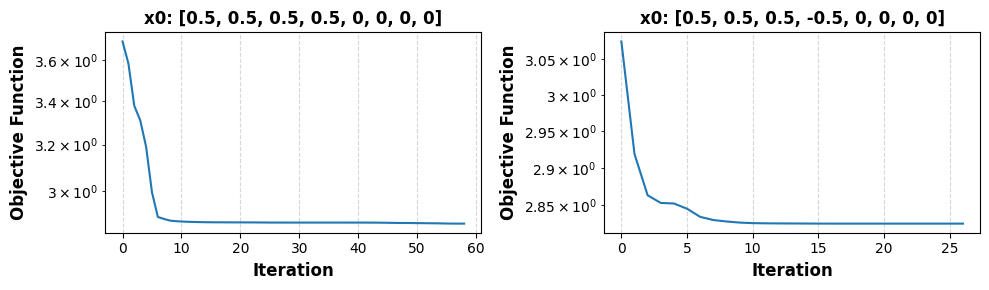

In [22]:
# Experiment 1, sum of relative errors
def exp1_err(H:np.ndarray, H_prime:np.ndarray)->float:
  rel_h_diff = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
  rel_v_diff = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
  rel_a_diff = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])
  return rel_h_diff + rel_v_diff + rel_a_diff

def exp1_obj(x):
  """
  returns value of the objective function at x, where 
  x = [a0, a1, a2, a3, b0, b1, b2, b3]
  """
  a0, a1, a2, a3, b0, b1, b2, b3 = x
  total_rel_error = 0
  for idx in range(data.shape[0]):
    H = get_H_gt(idx, data)
    H_prime = get_H_prime(a0, a1, a2, a3, b0, b1, b2, b3, idx, data)
    rel_error = exp1_err(H, H_prime)

    total_rel_error += rel_error
  
  return total_rel_error/data.shape[0]

fig, ax = plt.subplots(1, 2, figsize=(10,3))
results_1 = []
for i, x0 in tqdm(enumerate(x0s)):
  # run optimizer
  res = minimize(exp1_obj, x0, method='BFGS', options={'return_all': True})
  
  # loss-iteration plot
  losses = [exp1_obj(x) for x in res.allvecs]
  ax[i].plot(range(len(losses)),losses)
  ax[i].set_xlabel("Iteration", fontsize=12, fontweight="bold")
  ax[i].set_ylabel("Objective Function", fontsize=12, fontweight="bold")
  ax[i].set_title(f"x0: {x0}", fontsize=12, fontweight="bold")
  ax[i].grid(linestyle="--", alpha=0.5)
  ax[i].set_yscale("log")

  results_1.append(res)

plt.tight_layout()

# print best initial starting point
fun_values = [r.fun for r in results_1]
min_val = np.min(fun_values)
min_idx = np.argmin(fun_values)
print(f"minimum value: {min_val}; set: {x0s[min_idx]}")

In [23]:
# print the least values
idx = 3
best_res = results_1[1]
x = best_res.x
print(f"x:{x}")
# x = [2.58978044e-1, 3.79224673e-1, 6.22877983e-1, -4.19814564e-1,
#   2.60203661e-4, 2.23818366e-5, 3.29856168e-4, -8.28700472e-4]

H = get_H_gt(idx, data)
H_prime = get_H_prime(*x, idx, data)

h_rel_error = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
v_rel_error = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
a_rel_error = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])

print(f"h rel err: {h_rel_error:.6f}; h gt: {H[0,:]}, h prime: {H_prime[0,:]}")
print(f"v rel err: {v_rel_error:.6f}; v gt: {H[1,:]}, v prime: {H_prime[1,:]}")
print(f"a rel err: {a_rel_error:.6f}; a gt: {H[2,:]}, a prime: {H_prime[2,:]}")

x:[ 2.58978044e-01  3.79224673e-01  6.22877983e-01 -4.19814564e-01
  2.60203661e-04  2.23818366e-05  3.29856168e-04 -8.28700472e-04]
h rel err: 0.459536; h gt: [  917.98088025 -6551.96542365   -90.56256004], h prime: [-1025.68253025 -4543.43049781  1106.49862331]
v rel err: 0.554500; v gt: [3277.74965577  380.13270739 5733.04727227], v prime: [4121.57816689 -516.43787365 2277.9418421 ]
a rel err: 0.688936; a gt: [-0.85390115 -0.13794123  0.50182173], a prime: [-0.36900183  0.1118313   0.92267622]


0it [00:00, ?it/s]

2it [12:41, 380.90s/it]


minimum value: 20.081678851109718; set: [0.5, 0.5, 0.5, 0.5, 0, 0, 0, 0]


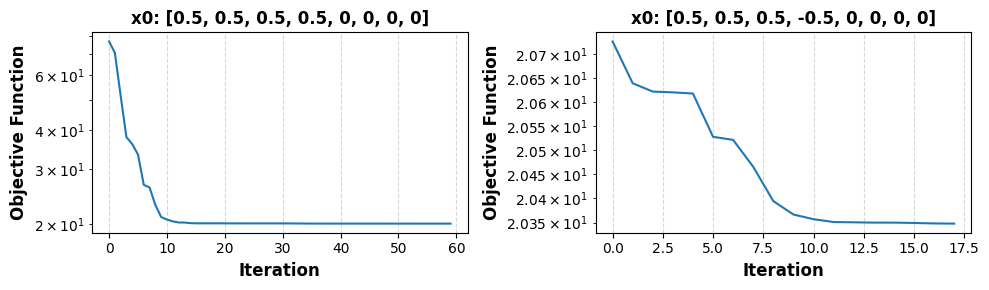

In [29]:
# Experiment 2, relative error for all matrix points
def exp2_err(H:np.ndarray, H_prime:np.ndarray)->float:
  return np.sum(np.abs((H - H_prime))/np.abs(H))

def exp2_obj(x):
  """
  returns value of the objective function at x, where 
  x = [a0, a1, a2, a3, b0, b1, b2, b3]
  """
  a0, a1, a2, a3, b0, b1, b2, b3 = x
  total_rel_error = 0
  for idx in range(data.shape[0]):
    H = get_H_gt(idx, data)
    H_prime = get_H_prime(a0, a1, a2, a3, b0, b1, b2, b3, idx, data)
    rel_error = exp2_err(H, H_prime)

    total_rel_error += rel_error
  
  return total_rel_error/data.shape[0]


fig, ax = plt.subplots(1, 2, figsize=(10,3))
results_2 = []
for i, x0 in tqdm(enumerate(x0s)):
  # run optimizer
  res = minimize(exp2_obj, x0, method='BFGS', options={'return_all': True})
  
  # loss-iteration plot
  losses = [exp2_obj(x) for x in res.allvecs]
  ax[i].plot(range(len(losses)),losses)
  ax[i].set_xlabel("Iteration", fontsize=12, fontweight="bold")
  ax[i].set_ylabel("Objective Function", fontsize=12, fontweight="bold")
  ax[i].set_title(f"x0: {x0}", fontsize=12, fontweight="bold")
  ax[i].grid(linestyle="--", alpha=0.5)
  ax[i].set_yscale("log")


  results_2.append(res)

plt.tight_layout()

# print best initial starting point
fun_values = [r.fun for r in results_2]
min_val = np.min(fun_values)
min_idx = np.argmin(fun_values)
print(f"minimum value: {min_val}; set: {x0s[min_idx]}")

In [31]:
# print the least values
idx = 3
best_res = results_2[0]
x = best_res.x
print(f"x:{x}")

H = get_H_gt(idx, data)
H_prime = get_H_prime(*x, idx, data)

h_rel_error = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
v_rel_error = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
a_rel_error = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])

print(f"h rel err: {h_rel_error:.6f}; h gt: {H[0,:]}, h prime: {H_prime[0,:]}")
print(f"v rel err: {v_rel_error:.6f}; v gt: {H[1,:]}, v prime: {H_prime[1,:]}")
print(f"a rel err: {a_rel_error:.6f}; a gt: {H[2,:]}, a prime: {H_prime[2,:]}")

x:[ 2.48493832  0.9270492   2.58229372 -0.10982538  0.27501092 -0.27042694
 -0.27311307 -0.28007   ]
h rel err: 1.689448; h gt: [  917.98088025 -6551.96542365   -90.56256004], h prime: [1139.50515384 4613.49116299 -579.95847099]
v rel err: 0.303481; v gt: [3277.74965577  380.13270739 5733.04727227], v prime: [2771.38084449  -62.96127083 3841.69464574]
a rel err: 1.987714; a gt: [-0.85390115 -0.13794123  0.50182173], a prime: [ 0.8673105  -0.08272556 -0.49084516]


To check the robustness of our initial starting point under the first regime, we would apply small perturbations to $x_0$ and check if the algorithm would reach the same objective function value

In [ ]:
# Experiment 1, sum of relative errors
def exp1_err(H:np.ndarray, H_prime:np.ndarray)->float:
  rel_h_diff = np.linalg.norm(H[0,:] - H_prime[0,:])/np.linalg.norm(H[0,:])
  rel_v_diff = np.linalg.norm(H[1,:] - H_prime[1,:])/np.linalg.norm(H[1,:])
  rel_a_diff = np.linalg.norm(H[2,:] - H_prime[2,:])/np.linalg.norm(H[2,:])
  return rel_h_diff + rel_v_diff + rel_a_diff

def exp1_obj(x):
  """
  returns value of the objective function at x, where 
  x = [a0, a1, a2, a3, b0, b1, b2, b3]
  """
  a0, a1, a2, a3, b0, b1, b2, b3 = x
  total_rel_error = 0
  for idx in range(data.shape[0]):
    H = get_H_gt(idx, data)
    H_prime = get_H_prime(a0, a1, a2, a3, b0, b1, b2, b3, idx, data)
    rel_error = exp1_err(H, H_prime)

    total_rel_error += rel_error
  
  return total_rel_error/data.shape[0]

x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res = minimize(exp1_obj, x0, method='BFGS', options={''})

#### Nelder Mead Algorithm

In [110]:
x0 = [0.1, 0.2, 0.3, 0.4, 0.01, 0.02, 0.03, 0.04]
res = minimize(obj, x0, method='Nelder-Mead', options={'disp': True})
print(res)

Optimization terminated successfully.
         Current function value: 19.496511
         Iterations: 534
         Function evaluations: 836
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 19.496511206922648
             x: [ 3.238e-01 -5.268e-01  5.037e-01 -9.229e-01  1.932e-02
                 -1.965e-02  1.962e-02  1.936e-02]
           nit: 534
          nfev: 836
 final_simplex: (array([[ 3.238e-01, -5.268e-01, ...,  1.962e-02,
                         1.936e-02],
                       [ 3.238e-01, -5.268e-01, ...,  1.962e-02,
                         1.936e-02],
                       ...,
                       [ 3.238e-01, -5.268e-01, ...,  1.962e-02,
                         1.936e-02],
                       [ 3.238e-01, -5.267e-01, ...,  1.962e-02,
                         1.936e-02]]), array([ 1.950e+01,  1.950e+01,  1.950e+01,  1.950e+01,
                        1.950e+01,  1.950e+01,  1.950e+01,  1.950e+01,
   


## Fitting the rotation instead

Here we want to model the rotation matrix from the mast frame to the camera frame, $R_M^C$. For a given data point $i$, let 
$H^r = \begin{bmatrix}h_i^T\\v_i^T\\a_i^T\end{bmatrix}$. Then $R_C^M$ is related to $H^r$ by the following

$$ H^r =  K^C R_C^M R_M^{r'} R_{r'}^r$$

Now because $R_{r'}^r$ and $R_m^{r'}$ are orthogonal matrices, so 
$(R_{r'}^r)^{-1} = (R_{r'}^r)^T $ and 
$(R_m^{r'})^{-1} = (R_m^{r'})^T$. Observe that $K^c$ is an upper triangular matrix
and there are no zeros on the main diagonal, so it is invertible. The inverse can 
be attained by using backward substitution

$$ (K^c)^{-1} = 
\begin{bmatrix} 
  \frac{1}{f+b_1} & -\frac{b_2}{f(f+b_1)} & \frac{c_yb_2}{f(f+b_1)}-\frac{c_x}{f+b_1}\\
  0 & \frac{1}{f} & -\frac{c_y}{f}\\
  0 & 0 & 1
\end{bmatrix} $$

So we have

$$R_C^M = (K^C)^{-1} H^r (R_{r'}^r)^T (R^r_m)^{T} \rightarrow q_C^M$$

We model the rotation as a function of focal length, $f$, in terms of quaternions 
$(q_C^{M})' = \alpha + f \cdot \beta$, where $\alpha$ and $\beta$ are quaternions.

The objective function would then be to find $\alpha$ and $\beta$ the solves 

$$ \min_{\alpha, \beta} \sum_{i} \|(q_C^M)_i - (q_C^M)'_i\|^2_2 = \min_{\alpha, \beta} \phi(\alpha, \beta) $$



Then the jacobian is given as 

$$

\triangledown \phi =
\sum_i
\begin{bmatrix}
  2(\alpha_0 + \beta_0f_i-(q_0)_i)\\
  2(\alpha_1 + \beta_1f_i-(q_1)_i)\\
  2(\alpha_2 + \beta_2f_i-(q_2)_i)\\
  2(\alpha_3 + \beta_3f_i-(q_3)_i)\\
  2(\alpha_0 + \beta_0f_i-(q_0)_i)f_i\\
  2(\alpha_1 + \beta_1f_i-(q_1)_i)f_i\\
  2(\alpha_2 + \beta_2f_i-(q_2)_i)f_i\\
  2(\alpha_3 + \beta_3f_i-(q_3)_i)f_i
\end{bmatrix}
$$


In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["h_r_vec" ] = [to_vec_comma(v) for v in data["h_r"]]
data["v_r_vec" ] = [to_vec_comma(v) for v in data["v_r"]]
data["a_r_vec" ] = [to_vec_comma(v) for v in data["a_r"]]
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]


Number of data points:3529


In [3]:
left_fl = {"alpha": 4684.257100, "beta": 0.0497613}
right_fl = {"alpha": 4689.772199, "beta": 0.053044}

def get_H_gt(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = data_["h_r_vec"][idx]
  v_i = data_["v_r_vec"][idx]
  a_i = data_["a_r_vec"][idx]
  H_i = np.vstack([h_i, v_i, a_i])

  return H_i

def get_R_rm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Calculates R_rpm @ R_rrp
  """
  R_rpm = data_["R_rpm_mat"][idx]
  q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
  R_rrp = R.from_quat(q_rrp).as_matrix()

  return R_rpm @ R_rrp

def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1"][idx], data_["b2"][idx], data_["cx"][idx], data_["cy"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_R_mc(a0:float, a1:float, a2:float, a3:float,
            b0:float, b1:float, b2:float, b3:float,
            idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the R_mc matrix where a0...a3 are the constants and b0...b3 are the scalar multiples
  """
  f = data_["fmc"][idx]

  
  q_mc = np.array([a0+b0*f, a1+b1*f, a2+b2*f, a3+b3*f])
  q_mc = q_mc / np.linalg.norm(q_mc)

  R_mc = R.from_quat(q_mc).as_matrix()

  return R_mc

def get_H_prime(a0:float, a1:float, a2:float, a3:float,
            b0:float, b1:float, b2:float, b3:float,
            idx:int, data_:np.ndarray):
  
  """
  Calculates the apprimaxations of H where a0...a3, b0...b3 are the quaternions for the rotation
  """
  Kc = get_KC(idx, data_)
  R_mc = get_R_mc(a0, a1, a2, a3, b0, b1, b2, b3, idx, data_)
  R_rm = get_R_rm(idx, data_)
  H_prime = Kc @ R_mc @ R_rm

  return H_prime

In [4]:
## precompute the quaternions
data["q_mc"] = [None]*data.shape[0]
q0s, q1s, q2s, q3s = [], [], [], []
for idx in range(data.shape[0]):
  Kc_inv = get_KC_inv(idx, data)
  H = get_H_gt(idx, data)
  R_rm = get_R_rm(idx, data)

  R_mc = Kc_inv @ H @ R_rm 
  rot = R.from_matrix(R_mc)
  q_mc = rot.as_quat()
  if (q_mc[0]<0):
    q_mc = -q_mc
  q0s.append(q_mc[0])
  q1s.append(q_mc[1])
  q2s.append(q_mc[2])
  q3s.append(q_mc[3])
  
data["q_mc_0"], data["q_mc_1"], data["q_mc_2"], data["q_mc_3"] = q0s, q1s, q2s, q3s

In [12]:
def gen_obj_jac(_data):

  def obj(x):
    a0, a1, a2, a3, b0, b1, b2, b3 = x
    res = 0
    for idx in range(_data.shape[0]):
      f = float(_data["fmc"][idx])
      q0 = _data["q_mc_0"][idx]
      q1 = _data["q_mc_1"][idx]
      q2 = _data["q_mc_2"][idx]
      q3 = _data["q_mc_3"][idx]
      res += (a0 + b0 * f - q0)**2 + (a1 + b1 * f - q1)**2 + (a2 + b2 * f - q2)**2 + (a3 + b3 * f - q3)**2
    
    return res/_data.shape[0]

  def jac(x):
    a0, a1, a2, a3, b0, b1, b2, b3 = x
    jac = np.zeros(8)

    for idx in range(_data.shape[0]):
      f = float(_data["fmc"][idx])
      

      jac += np.array([2*(a0+b0*f-_data["q_mc_0"][idx]),
                      2*(a1+b1*f-_data["q_mc_1"][idx]),
                      2*(a2+b2*f-_data["q_mc_2"][idx]),
                      2*(a3+b3*f-_data["q_mc_3"][idx]),
                      2*(a0+b0*f-_data["q_mc_0"][idx])*f,
                      2*(a1+b1*f-_data["q_mc_1"][idx])*f,
                      2*(a2+b2*f-_data["q_mc_2"][idx])*f,
                      2*(a3+b3*f-_data["q_mc_3"][idx])*f])
    
    return jac/_data.shape[0]
  
  return obj, jac

In [13]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)
zl034_obj, zl034_jac = gen_obj_jac(zl034_data)
x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res = minimize(zl034_obj, x0, method="BFGS", jac=zl034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:4]}")
print(f"beta:{res.x[4:]}")
  

Final function:0.000000
Final Jacobian:0.000000
alpha:[ 0.48950704  0.50881156  0.50325955 -0.49822021]
beta:[ 9.00746376e-08 -1.36169512e-07 -6.17753520e-08 -1.12856380e-07]


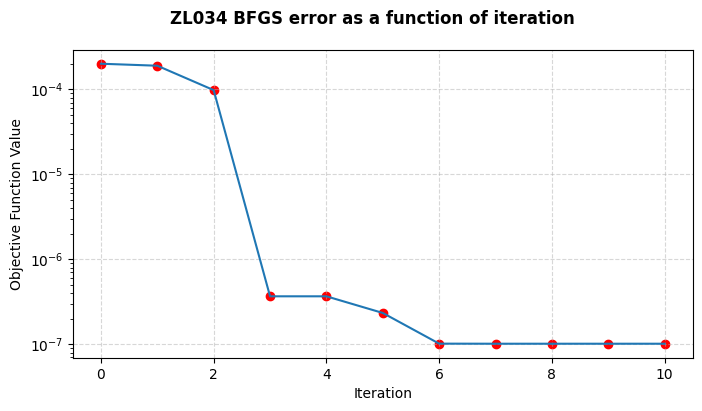

In [14]:
# plot the error as a function of iteration
errs = [zl034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 BFGS error as a function of iteration", 
             fontsize=12, fontweight="bold");

In [15]:
zr034_data = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)
zr034_obj, zr034_jac = gen_obj_jac(zr034_data)
x0 = [0.5, 0.5, 0.5, -0.5, 0, 0, 0, 0]
res = minimize(zr034_obj, x0, method="BFGS", jac=zr034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:4]}")
print(f"beta:{res.x[4:]}")

Final function:0.000030
Final Jacobian:0.000000
alpha:[ 0.50678693  0.49067444  0.4958249  -0.50646536]
beta:[-1.65644578e-06 -3.13411634e-06 -1.60222573e-06 -6.20323604e-06]


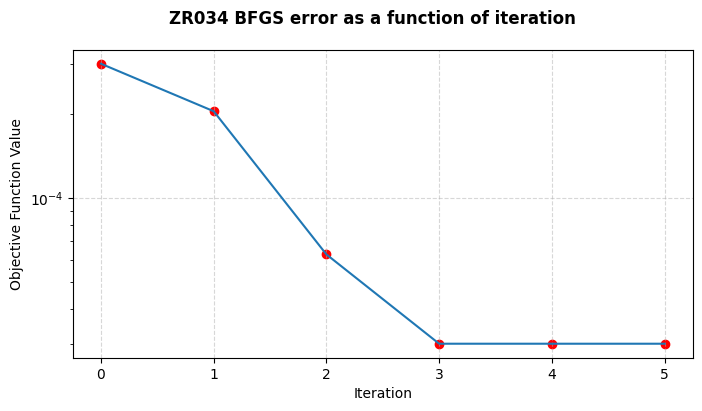

In [16]:
# plot the error as a function of iteration
errs = [zr034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", 
             fontsize=12, fontweight="bold");

## Camera Model Fitting

Here we want to fit the camera vector in the mast frame, $c^M$. Here we know the camera vector in the rover frame $c^r$, and they are related by 

 
 \begin{align}
  \begin{bmatrix} c^r \\ 1 \end{bmatrix} 
  &= T^r_{r'} T^{r'}_{m} \begin{bmatrix} c^m \\ 1 \end{bmatrix}\\
  
  &= \begin{bmatrix} R^r_{r'} & t^r_{r'}\\ 0 & 1/s_{r'}^r \end{bmatrix}
  \begin{bmatrix} R^{r'}_m & t^{r'}_m\\ 0 & 1 \end{bmatrix}
  \begin{bmatrix} c^m \\ 1 \end{bmatrix}\\

  &= \begin{bmatrix} (R^r_{r'}R^{r'}_mc^m + R^r_{r'}t_m^{r'}+t_{r'}^r) \\ 1/s_{r'}^r\end{bmatrix}
  \end{align}

Normalizing and comparing the non-homogeneous components,

$$R^r_{r'}R_m^{r'}c^m = \frac{1}{s^r_{r'}} c^r - t^r_{r'} - R_{r'}^rt_m^{r'}$$

Now becuase the rotation matrices $R^r_{r'}$,$R_m^{r'}$ are orthogonal, then their inverse are their transpose, so 
$$c^m = (R^r_{r'})^T(R_m^{r'})^T\left(\frac{1}{s^r_{r'}} c^r - t^r_{r'} - R_{r'}^rt_m^{r'}\right)$$

We let this above value derived from the datat be the ground truth. 

Now, we want to model the camera vector in the mast frame as a function of focus motor count, $f$, as the following 

  $$ (c^m)' = \alpha + \beta \cdot f 
  = \begin{bmatrix} \alpha_0 \\ \alpha_1 \\ \alpha_2 \end{bmatrix} + f \cdot \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{bmatrix}
  = \begin{bmatrix} \alpha_0 + \beta_0f \\ \alpha_1 + \beta_1f \\ \alpha_2 + \beta_2f \end{bmatrix} $$

and we want to find $\alpha$ and $\beta$ that solves

  $$ \min_{\alpha,\beta} \sum_i \|(c^m)'_i - c^m_i\|^2_2 = \phi(\alpha, \beta)$$

where $\phi$ is the objective function and the jacobian function is 

  $$ \triangledown \phi = \sum_i
  \begin{bmatrix}
    2(\alpha_0 + \beta_0 f_i - c_{0,i})\\
    2(\alpha_1 + \beta_1 f_i - c_{1,i})\\
    2(\alpha_2 + \beta_2 f_i - c_{2,i})\\
    2(\alpha_0 + \beta_0 f_i - c_{0,i})f_i\\
    2(\alpha_1 + \beta_1 f_i - c_{1,i})f_i\\
    2(\alpha_2 + \beta_2 f_i - c_{2,i})f_i\\
  \end{bmatrix} $$

In [17]:
data_path = "data/m41_site_cal_v227_v8.xlsx"


data = pd.read_excel(data_path)
print(f"Number of data points:{data.shape[0]}")

# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# convert strings to vecs/mats
data["R_rpm_mat"] = [to_mat(m) for m in data["R_rpm"]]
data["t_rpm_vec"] = [to_vec_comma(t) for t in data["t_rpm"]]
data["c_r_vec"] = [to_vec_comma(c) for c in data["c_r"]]

Number of data points:3529


In [ ]:
# precompute the camera vectors from data
q_rrp = np.array([0.00035132, -0.0004781 ,  0.00048555, -0.99999971])
R_rrp = R.from_quat(q_rrp).as_matrix()
t_rrp = np.array([0.0007, 0.003, 0.0006])
s_rrp = 0.998

data["c_m"] = [None]*data.shape[0]
for idx in range(data.shape[0]):
  R_rpm = data["R_rpm_mat"][idx]
  t_rpm = data["t_rpm_vec"][idx]
  c_r = data["c_r_vec"][idx]
  data["c_m"][idx] = R_rpm.T @ R_rrp.T @ ((1/s_rrp)*c_r - t_rrp - R_rrp @ t_rpm)

x_mean:0.031314, y_mean:-0.124092, z_mean:-0.068550


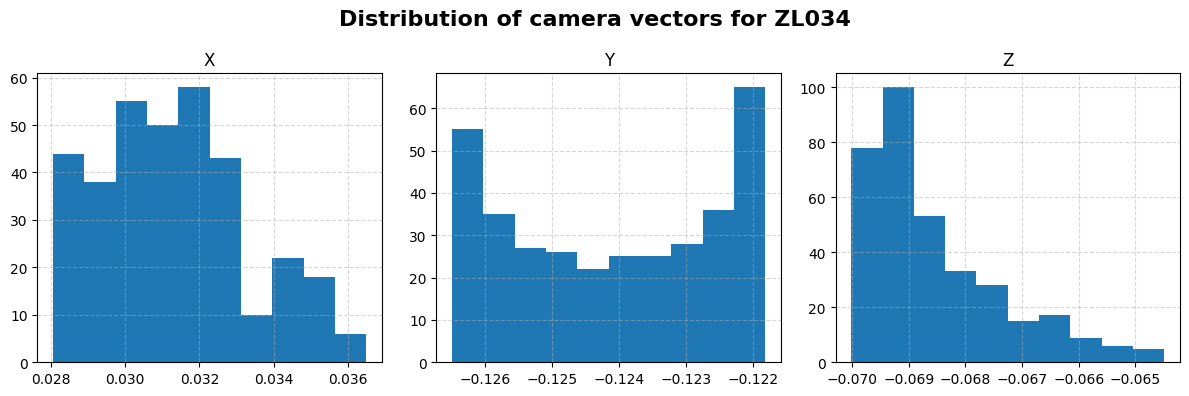

In [28]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)

# plot the distribution of the camera vectors
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].hist(zl034_data["c_m"].apply(lambda x: x[0]))
ax[0].set_title("X")
ax[0].grid(linestyle="--", alpha=0.5)

ax[1].hist(zl034_data["c_m"].apply(lambda x: x[1]))
ax[1].set_title("Y")
ax[1].grid(linestyle="--", alpha=0.5)

ax[2].hist(zl034_data["c_m"].apply(lambda x: x[2]))
ax[2].set_title("Z")
ax[2].grid(linestyle="--", alpha=0.5)

plt.suptitle("Distribution of camera vectors for ZL034", fontsize=16, fontweight="bold")
plt.tight_layout()

x_mean = zl034_data["c_m"].apply(lambda x: x[0]).mean()
y_mean = zl034_data["c_m"].apply(lambda x: x[1]).mean()
z_mean = zl034_data["c_m"].apply(lambda x: x[2]).mean()
print(f"x_mean:{x_mean:.6f}, y_mean:{y_mean:.6f}, z_mean:{z_mean:.6f}")

In [37]:
def gen_obj_jac_cam(_data):

  def obj(x):
    a0, a1, a2, b0, b1, b2 = x
    res = 0
    for idx in range(_data.shape[0]):
      f = _data["fmc"][idx]
      c = _data["c_m"][idx]
      res += (a0 + b0 * f - c[0])**2 + (a1 + b1 * f - c[1])**2 + (a2 + b2 * f - c[2])**2
    
    return res

  def jac(x):
    a0, a1, a2, b0, b1, b2 = x
    j = np.ones(6)

    for idx in range(_data.shape[0]):
      f = _data["fmc"][idx]
      c = _data["c_m"][idx]

      j += np.array([2*(a0+b0*f-c[0]),
                      2*(a1+b1*f-c[1]),
                      2*(a2+b2*f-c[2]),
                      2*(a0+b0*f-c[0])*f,
                      2*(a1+b1*f-c[1])*f,
                      2*(a2+b2*f-c[2])*f])
    return j/_data.shape[0]

  return obj, jac


In [ ]:
zl034_data = data[data["cam"]=="ZL034"].copy().reset_index(drop=True)
zl034_obj, zl034_jac = gen_obj_jac_cam(zl034_data)
x0 = [1, -1, -1, 0, 0, 0]
res = minimize(zl034_obj, x0, method="BFGS", jac=zl034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:3]}")
print(f"beta:{res.x[3:]}")

Final function:0.004158
Final Jacobian:0.000001
alpha:[ 3.00873504e-02 -1.25485329e-01 -6.99179800e-02 -1.10891505e-06]
beta:[-2.94247468e-07 -4.19201638e-07]


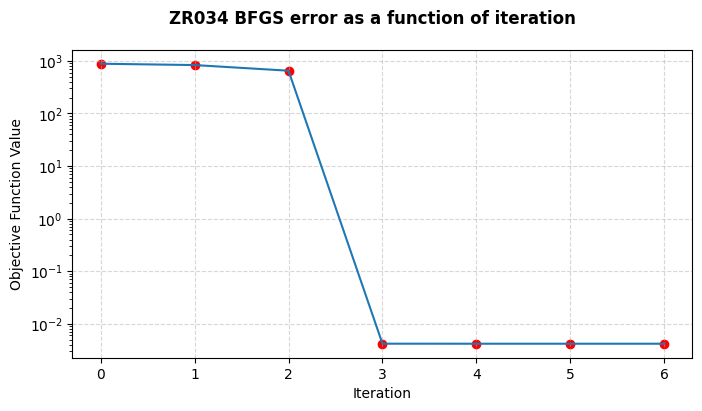

In [44]:
# plot the error as a function of iteration
errs = [zl034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [45]:
zr034_data = data[data["cam"]=="ZR034"].copy().reset_index(drop=True)
zr034_obj, zr034_jac = gen_obj_jac_cam(zr034_data)
x0 = [1, -1, -1, 0, 0, 0]
res = minimize(zr034_obj, x0, method="BFGS", jac=zr034_jac, options={"return_all":True, "gtol":1e-20, "xrtol":1e-20})

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"alpha:{res.x[:4]}")
print(f"beta:{res.x[4:]}")

Final function:0.004426
Final Jacobian:0.001690
alpha:[ 3.20263526e-02  1.18305906e-01 -7.03304835e-02  1.09500225e-06]
beta:[-2.71687146e-09 -8.08768353e-08]


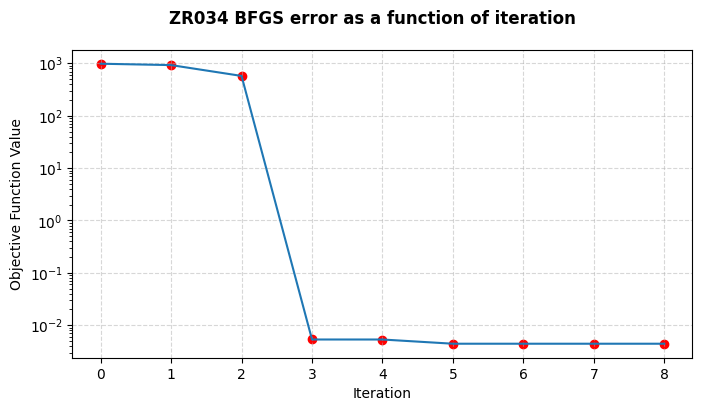

In [46]:
# plot the error as a function of iteration
errs = [zr034_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");